## Now we will manipulate the LV model under diff conditions:
- all rabbits/wolves are eaten at the start
- rabbits/wolves get a disease in the middle and die off (slowly, not all at once)
- Having a carrying capacity - where there is a fixed set of rabbits to exist (user-capped, not by nature)
- etc.

In [ ]:
!uv pip show matplotlib

Name: matplotlib
Version: 3.10.8
Location: /Users/benhorvath/Desktop/cispa/n-odes/ode-exploration/.venv/lib/python3.11/site-packages
Requires: contourpy, cycler, fonttools, kiwisolver, numpy, packaging, pillow, pyparsing, python-dateutil
Required-by:


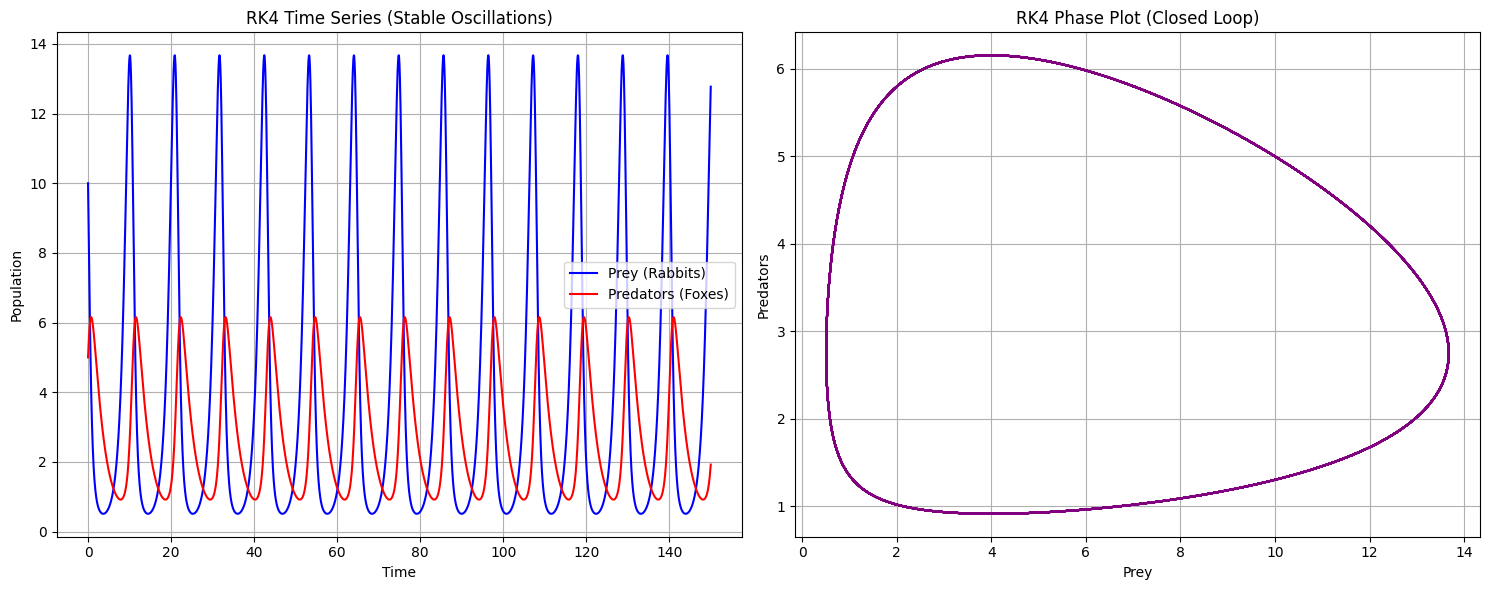

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Differential Equations (No Carrying Capacity)
def system_dynamics(z, a, b, c, d):
    x, y = z
    dxdt = a * x - b * x * y
    dydt = d * x * y - c * y
    return np.array([dxdt, dydt])

# 2. Parameters (Matching the clean oscillations in your image)
a, b, c, d = 1.1, 0.4, 0.4, 0.1
dt = 0.05       # RK4 is stable enough for a larger dt than Euler
t_final = 150
steps = int(t_final / dt)

# 3. Initialize storage
results = np.zeros((steps, 2))
t = np.linspace(0, t_final, steps)
z = np.array([10.0, 5.0]) # Initial populations: [Prey, Predator]

# 4. The RK4 Simulation Loop
for i in range(steps):
    results[i] = z
    
    # Calculate the 4 trial slopes (k values)
    k1 = system_dynamics(z, a, b, c, d)
    k2 = system_dynamics(z + (dt/2)*k1, a, b, c, d)
    k3 = system_dynamics(z + (dt/2)*k2, a, b, c, d)
    k4 = system_dynamics(z + dt*k3, a, b, c, d)
    
    # Update state using weighted average: (k1 + 2k2 + 2k3 + k4) / 6
    z = z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# Split results for plotting
prey, predators = results.T

# 5. Visualization: Time Series and Phase Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Time Series
ax1.plot(t, prey, label='Prey (Rabbits)', color='blue')
ax1.plot(t, predators, label='Predators (Foxes)', color='red')
ax1.set_title('RK4 Time Series (Stable Oscillations)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Population')
ax1.legend()
ax1.grid(True)

# Phase Plot
ax2.plot(prey, predators, color='purple')
ax2.set_title('RK4 Phase Plot (Closed Loop)')
ax2.set_xlabel('Prey')
ax2.set_ylabel('Predators')
ax2.grid(True)

plt.tight_layout()
plt.show()

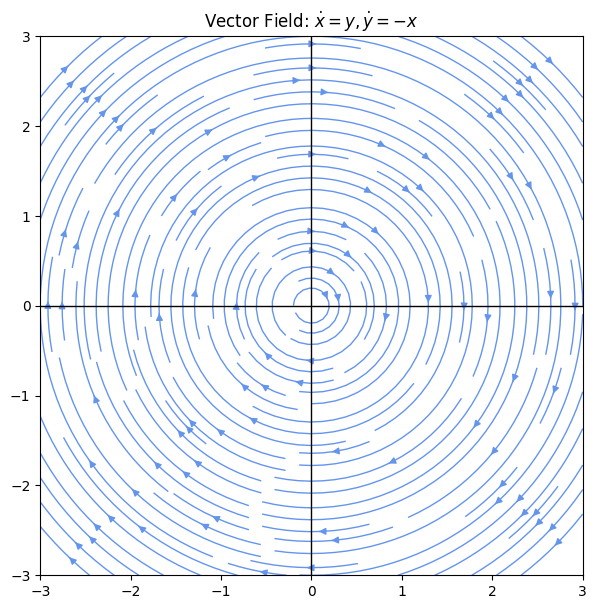

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the ODE system: dx/dt = y, dy/dt = -x (Simple Harmonic Oscillator)
def system(X, Y):
    u = Y
    v = -X
    return u, v

# 2. Create a grid of points
w = 3
x = np.linspace(-w, w, 20)
y = np.linspace(-w, w, 20)
X, Y = np.meshgrid(x, y)

# 3. Compute the vectors at each point
U, V = system(X, Y)

# 4. Plot
plt.figure(figsize=(7, 7))
plt.streamplot(X, Y, U, V, color='cornflowerblue', linewidth=1, density=1.5)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Vector Field: $\dot{x}=y, \dot{y}=-x$")
plt.show()

interactive(children=(FloatSlider(value=1.1, description='Prey Birth (a)', max=2.0), FloatSlider(value=0.4, de…

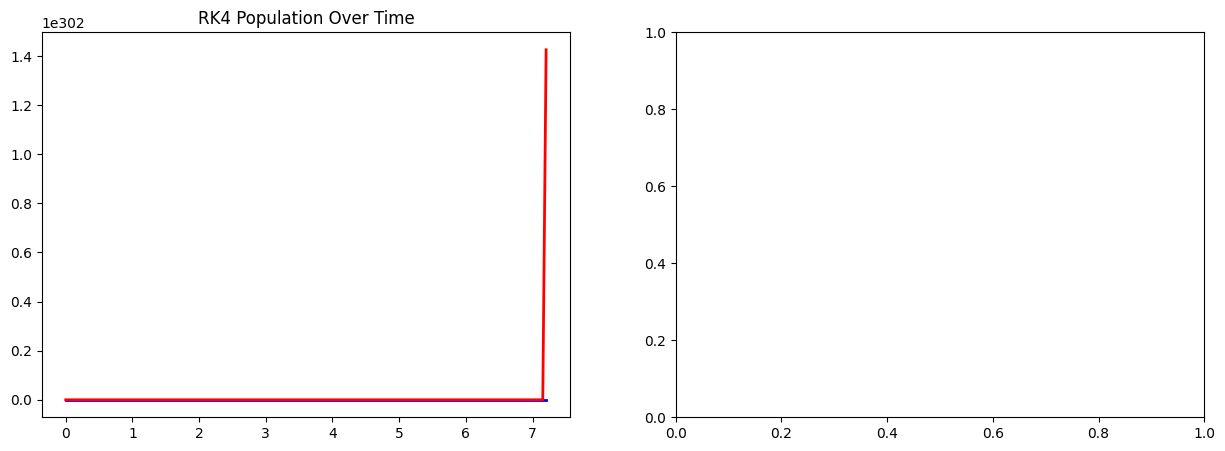

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# 1. Define the system
def system_dynamics(z, a, b, c, d):
    x, y = z
    dxdt = a * x - b * x * y
    dydt = d * x * y - c * y
    return np.array([dxdt, dydt])

# 2. Define the update/plotting function for the sliders
@interact(
    a=FloatSlider(min=0, max=5.0, step=0.1, value=1.1, description='Prey Birth (a)'),
    b=FloatSlider(min=0, max=1.0, step=0.05, value=0.4, description='Efficiency of Predation (b)'),
    c=FloatSlider(min=0, max=2.0, step=0.1, value=0.4, description='Fox Death (c)',style={'description_width': 'initial'}),
    d=FloatSlider(min=0, max=0.5, step=0.01, value=0.1, description='Predator Birth (d)',style={'description_width': 'initial'})
    # should change:
    # a = 0-2 ; to 0-5
    # b = 0-1 ; to 0.01 - 0.5
    # c = 0-2 ; to 0.1 - 4.0
    # d = 0-0.5 ; to 0.01-1

)
def update_simulation(a, b, c, d):
    dt = 0.05
    t_final = 100 # Reduced slightly for snappier slider response
    steps = int(t_final / dt)

    # Initialize
    results = np.zeros((steps, 2))
    t = np.linspace(0, t_final, steps)
    z = np.array([10.0, 5.0]) 

    # RK4 Loop
    for i in range(steps):
        results[i] = z
        k1 = system_dynamics(z, a, b, c, d)
        k2 = system_dynamics(z + (dt/2)*k1, a, b, c, d)
        k3 = system_dynamics(z + (dt/2)*k2, a, b, c, d)
        k4 = system_dynamics(z + dt*k3, a, b, c, d)
        z = z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    prey, predators = results.T

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Time Series
    ax1.plot(t, prey, label='Prey', color='blue', lw=2)
    ax1.plot(t, predators, label='Predators', color='red', lw=2)
    ax1.set_title('RK4 Population Over Time')
    ax1.set_ylim(0, max(np.max(prey), np.max(predators)) * 1.1)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Phase Plot
    ax2.plot(prey, predators, color='purple', lw=2)
    ax2.set_title('Phase Space (Prey vs Predators)')
    ax2.set_xlabel('Prey Population')
    ax2.set_ylabel('Predator Population')
    ax2.grid(alpha=0.3)

    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider

def plot_predator_prey(alpha, beta, delta, gamma):
    # ODE: dr/dt = alpha*r - beta*r*f, df/dt = delta*r*f - gamma*f
    def deriv(t, y):
        r, f = y
        return [alpha*r - beta*r*f, delta*r*f - gamma*f]

    # Solve the system
    t_span = (0, 50)
    t_eval = np.linspace(0, 50, 1000)
    sol = solve_ivp(deriv, t_span, [10, 5], t_eval=t_eval)

    # Create the Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Time Series Plot
    ax1.plot(sol.t, sol.y[0], label='Prey (Rabbits)', color='skyblue')
    ax1.plot(sol.t, sol.y[1], label='Predators (Foxes)', color='salmon')
    ax1.set_xlabel('Time')
    ax1.legend()
    
    # Phase Plane Plot (Vector Field style)
    ax2.plot(sol.y[0], sol.y[1], color='purple')
    ax2.set_xlabel('Prey')
    ax2.set_ylabel('Predators')
    ax2.set_title('Phase Plane')
    
    plt.show()

# Create sliders
interact(plot_predator_prey, 
         alpha=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.1, 
                           description='alpha (prey birth rate)',
                           style={'description_width': 'initial'}),
         beta=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.4, 
                          description='beta (predation rate)',
                          style={'description_width': 'initial'}),
         delta=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.1, 
                           description='delta (fox birth rate)',
                           style={'description_width': 'initial'}),
         gamma=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.4, 
                           description='gamma (predator death rate)',
                           style={'description_width': 'initial'}))

interactive(children=(FloatSlider(value=1.1, description='alpha (prey birth rate)', max=2.0, min=0.1, style=Sl…

<function __main__.plot_predator_prey(alpha, beta, delta, gamma)>

Some interesting factors when observing this:
- When setting the birth rate of both the prey and predator, it is important to note that the phase space will not be complete, thus showing that this is evident of extinction and the balance of the environment is not complete/broken
- With settings a = 0.1 ; b = 0.3 ; c = 0.14 ; d = 0.8, this has an effect on the phase space where it shows to have an inwards focus
- This highlights the relationship between the predator and prey in a different modality; where when we reach a peak of the prey/predator, it will go back down towards the center. 
- When there is stability, there will be no inwards/outwards shift in the phase space.
  - However, this is highlighting an imbalance in the relationship.

![](img/v-low-prey.png)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider, Dropdown, IntSlider

def plot_disease_model(alpha, beta, delta, gamma, dis_outbreak, severity, target='Predator'):
    
    def deriv(t, y):
        r, f = y
        
        # Current death/birth rates
        current_alpha = alpha
        current_gamma = gamma
        
        # Apply disease effect after dis_outbreak
        if t > dis_outbreak:
            if target == 'Predator':
                # Increase predator death rate
                current_gamma += severity 
            else:
                # Decrease prey birth rate (or increase prey death)
                current_alpha -= severity
        
        # Standard Lotka-Volterra with modified rates
        dr_dt = current_alpha * r - beta * r * f
        df_dt = delta * r * f - current_gamma * f
        
        return [dr_dt, df_dt]

    t_span = (0, 100) # Increased time to see extinction play out
    t_eval = np.linspace(0, 100, 2000)
    sol = solve_ivp(deriv, t_span, [10, 5], t_eval=t_eval)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Time Series
    ax1.plot(sol.t, sol.y[0], label='Prey', color='skyblue')
    ax1.plot(sol.t, sol.y[1], label='Predators', color='salmon')
    ax1.axvline(dis_outbreak, color='black', linestyle='--', label='Disease Outbreak')
    ax1.set_xlabel('Time')
    ax1.set_title('Population over Time')
    ax1.legend()
    
    # Phase Plane
    ax2.plot(sol.y[0], sol.y[1], color='purple')
    ax2.set_xlabel('Prey')
    ax2.set_ylabel('Predators')
    ax2.set_title('Phase Plane (Path to Extinction)')
    
    plt.show()

interact(plot_disease_model, 
         alpha=FloatSlider(min=0.0, max=2.0, step=0.1, value=0.20, 
                           description='alpha (prey birth rate)',
                           style={'description_width': 'initial'}),
         beta=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.30, 
                          description='beta (predation rate)',
                          style={'description_width': 'initial'}),
         delta=FloatSlider(min=0.0, max=0.5, step=0.01, value=0.2, 
                           description='delta (fox birth rate)',
                           style={'description_width': 'initial'}),
         gamma=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.50, 
                           description='gamma (fox death rate)',
                           style={'description_width': 'initial'}),
         dis_outbreak=IntSlider(min=0, max=100, step=1, value=50,
                                description='Time of outbreak:',
                                style={'description_width': 'initial'}), 
         severity=(0, 10.0, 0.1),
         target=Dropdown(options=['Predator', 'Prey'], 
                         value='Predator', 
                         description='Species with Disease Outbreak:', 
                         style={'description_width': 'initial'}))

        # alpha=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.1, 
        #                 description='alpha (prey birth rate)',
        #                 style={'description_width': 'initial'}),
        # beta=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.4, 
        #                 description='beta (predation rate)',
        #                 style={'description_width': 'initial'}),
        # delta=FloatSlider(min=0.01, max=0.5, step=0.01, value=0.1, 
        #                 description='delta (fox birth rate)',
        #                 style={'description_width': 'initial'}),
        # gamma=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.4, 
        #                 description='gamma (predator death rate)',
        #                 style={'description_width': 'initial'}))

interactive(children=(FloatSlider(value=0.2, description='alpha (prey birth rate)', max=2.0, style=SliderStyle…

<function __main__.plot_disease_model(alpha, beta, delta, gamma, dis_outbreak, severity, target='Predator')>

In the above, we see two types of phases, before and after a disease outbreak. 

However, we must also consider what species is affected: 
- If the prey is affected, this would do a traditional flatline, as this would affect the food supply directly of the predators. 
- If the predators are slowly dying off, this would then cause the prey to exponentially increase. However, we see a weird phenomenon because the severity of the 


If the predators are extinct ($y=0$), the prey $x$ grows exponentially ($+ \alpha$). If the prey are extinct ($x=0$), the predators $y$ starve exponentially ($- \gamma$).

The Shape: This creates a Saddle. The "stable manifold" is the y-axis (flowing toward 0), and the "unstable manifold" is the x-axis (flowing away from 0). It is a point of total instability—nature doesn't want to stay at zero.

# Observing Critical Points:
## When looking at critical points, it is important to consider the Jacobian at different points:
- Sink
- Source
- Node
- Foci
- Center


In 2D systems, we look at the Eigenvalues ($\lambda$) of the Jacobian matrix at that point:
- **Real Eigenvalues:** You get Nodes (Sinks/Sources).
- **Complex Eigenvalues** ($a \pm bi$): You get Foci or Centers.
  - If the real part ($a$) is negative $\rightarrow$ Stable Focus.
  - If the real part ($a$) is positive $\rightarrow$ Unstable Focus.
  - If the real part ($a$) is zero $\rightarrow$ Center.




Sink, source and node apply to 1D terms, whereas foci and centre apply to 2D systems (systems of 2 differential equations)

# Sink vs Source
A sink:
- Occurs when all paths lead directly into a point 
- Ex: $f'(c) < 0$.
  - ie. Convergence w/ opp. being divergence/source
- Think of water flowing into the drain

A source:
- Occurs if the system is perturbed slightly, it moves further away from the point/center.
- Ex: $f'(c) > 0$.
  - ie. curl (ie. https://en.wikipedia.org/wiki/Curl_(mathematics))
  - Contains orthogonal vectors
  - Positive divergence 
- Input vectors will then turn into output vectors 
- Only spins around the center.

![](img/curl-divergence.png)

# Mostly when it comes to Pred-Prey models, we would see 